# GARCH on Latest R1 Features Dataset

This notebook builds a GARCH baseline on top of the latest `features_YYYYMMDD_HHMMSS.csv` file in `data/processed/`.

The goal is to compare GARCH against SARIMA across:

- three delay targets: `type_1_only`, `type_2_only`, `type_1_and_2`
- three day-type segments: `all_week`, `workday`, `weekend`

The earlier AR-lag GARCH version could produce explosive-looking forecasts because it used a recursive multi-step mean forecast on the delay **level** series. If the AR coefficients are near a non-stationary boundary, long-horizon level forecasts can drift unrealistically even when training data never showed that magnitude.

This notebook uses a more stable comparison baseline:

- split the data by day type the same way the earlier SARIMA workflow did conceptually
- fit a **constant-mean GARCH(1,1)** model within each segment
- evaluate the holdout mean forecast and the conditional volatility forecast

That makes GARCH act as a volatility-aware baseline instead of forcing it to mimic SARIMA's seasonal mean structure.

In [2]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

try:
    from arch import arch_model
except ImportError as exc:
    raise ImportError("This notebook requires the `arch` package in the active Jupyter environment.") from exc

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 100)

In [3]:
# Resolve the repo root robustly even when the notebook is launched from EDA/.
# EDA/data/models exists, so checking only for `data/` can incorrectly stop at
# PROJECT/EDA instead of the repo root. We require `data/processed`.
PROJECT_DIR = Path.cwd().resolve()
while PROJECT_DIR != PROJECT_DIR.parent and not (PROJECT_DIR / "data" / "processed").exists():
    PROJECT_DIR = PROJECT_DIR.parent

DATA_DIR = PROJECT_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"


def latest_features_file(processed_dir: Path) -> Path:
    candidates = sorted(
        path
        for path in processed_dir.glob("features_*.csv")
        if re.fullmatch(r"features_\d{8}_\d{6}\.csv", path.name)
    )
    if not candidates:
        raise FileNotFoundError("No timestamped features CSV found in data/processed/.")
    return candidates[-1]


def mae(y_true, y_pred):
    return np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred)))


def rmse(y_true, y_pred):
    return np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2))

In [4]:
features_path = latest_features_file(PROCESSED_DIR)
df = pd.read_csv(features_path)

for col in ["planned_arrival_dt", "actual_arrival_dt", "hour_trunc", "service_date"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

df_model = df[df["direction"].notna()].copy()

print(f"Loaded features file: {features_path.name}")
print(f"Original rows: {len(df):,}")
print(f"Rows with non-missing direction: {len(df_model):,}")
print(f"Date range: {df_model['service_date'].min().date()} -> {df_model['service_date'].max().date()}")
display(df_model["day_type"].value_counts(dropna=False))

Loaded features file: features_20260607_171047.csv
Original rows: 273,405
Rows with non-missing direction: 273,405
Date range: 2026-03-15 -> 2026-05-21


day_type
workday    202186
weekend     61153
holiday     10066
Name: count, dtype: int64

## 1. Build Hourly Series by Target and Day Segment

We evaluate three target definitions and three segment definitions:

- `all_week`: all rows together
- `workday`: only rows where `day_type == workday`
- `weekend`: only rows where `day_type == weekend`

**Critical design choice — how segmented series are constructed:**

The naive approach (filter rows, then reindex to the *full* 68-day date range) produces series where ~78% of `weekend` points and ~43% of `workday` points are linearly interpolated across multi-day gaps (e.g. 120 h of weekdays between two weekends). Fitting GARCH on such a series is fitting mostly on synthetic data, which is misleading.

The fix used here is to **stack only the actual observed hours contiguously**:

1. Filter to the day-type of interest.
2. Aggregate to hourly means **within that subset**.
3. Fill only *within-day* gaps (overnight hours with no service) by time-weighted interpolation.
4. Do **not** reindex to span the full multi-week calendar range.

This means the `workday` series is a sequence of ~49 × 19 = ~931 real observation-hours, and the `weekend` series is ~19 × 19 = ~361 real observation-hours. The GARCH model operates on these compact, real-data series rather than on a calendar-length series inflated by interpolated weekday/weekend gaps.

In [5]:
def build_hourly_delay_series(
    frame: pd.DataFrame,
    target_col: str,
    day_type: str | None = None,
) -> pd.Series:
    """Aggregate train-station rows to an hourly mean delay series.

    For segmented series (day_type is not None) we do NOT reindex to the full
    calendar date range. Instead, we reindex only within each individual
    service day so that overnight gaps (00:00-04:00, no trains) are filled by
    interpolation, but multi-day gaps between e.g. consecutive weekends are
    NOT filled. This prevents GARCH from being fitted on predominantly
    fabricated data.

    For the all_week series we still span the full range because every day
    contributes real observations and the overnight gap share is modest (~17%).

    Parameters
    ----------
    frame : pd.DataFrame   Feature table (direction-filtered).
    target_col : str       Delay column to aggregate.
    day_type : str | None  If given, filter to this day_type before aggregating.

    Returns
    -------
    pd.Series  Hourly mean delay, indexed by hour_trunc (Timestamp).
    """
    subset = frame.copy()
    if day_type is not None:
        subset = subset[subset["day_type"] == day_type].copy()

    subset = subset.dropna(subset=["hour_trunc", target_col])
    if subset.empty:
        return pd.Series(dtype=float)

    hourly = (
        subset.groupby("hour_trunc")[target_col]
        .mean()
        .sort_index()
    )

    if day_type is None:
        # all_week: reindex to full range (every day contributes real data)
        # freq="h" (lowercase) — "H" deprecated since pandas 2.2
        full_index = pd.date_range(hourly.index.min(), hourly.index.max(), freq="h")
        hourly = hourly.reindex(full_index)
        hourly = hourly.interpolate(method="time").ffill().bfill()
    else:
        # Segmented series: fill overnight gaps WITHIN each day only.
        # Iterate over unique service dates, build a complete hourly grid
        # for each day, interpolate, then stack — no cross-day gaps injected.
        service_dates = sorted(subset["hour_trunc"].dt.normalize().unique())
        day_series_list = []
        for day in service_dates:
            day_mask  = (hourly.index >= day) & (hourly.index < day + pd.Timedelta("1D"))
            day_slice = hourly[day_mask]
            if day_slice.empty:
                continue
            day_index = pd.date_range(day_slice.index.min(), day_slice.index.max(), freq="h")
            day_slice = day_slice.reindex(day_index).interpolate(method="time").ffill().bfill()
            day_series_list.append(day_slice)

        if not day_series_list:
            return pd.Series(dtype=float)
        hourly = pd.concat(day_series_list).sort_index()

    hourly.index.name = "timestamp"
    return hourly.astype(float)


df_model["delay_type_1_2_mean"] = df_model[["delay_type_1", "delay_type_2"]].mean(axis=1)

target_specs = {
    "type_1_only": "delay_type_1",
    "type_2_only": "delay_type_2",
    "type_1_and_2": "delay_type_1_2_mean",
}

target_notes = {
    "type_1_only": "Type 1 = last actual arrival - first planned arrival.",
    "type_2_only": "Type 2 = last actual arrival - last planned arrival.",
    "type_1_and_2": "Type 1&2 = row-wise mean of Type 1 and Type 2.",
}

segment_specs = {
    "all_week": None,
    "workday":  "workday",
    "weekend":  "weekend",
}

series_map = {}
summary_rows = []
for target_label, target_col in target_specs.items():
    for segment_label, segment_day_type in segment_specs.items():
        series = build_hourly_delay_series(df_model, target_col, day_type=segment_day_type)
        combo_key = (target_label, segment_label)
        series_map[combo_key] = series
        summary_rows.append({
            "target_variant": target_label,
            "segment":        segment_label,
            "target_column":  target_col,
            "n_hours":        len(series),
            "note": ("full calendar span" if segment_day_type is None
                     else "stacked real service hours only"),
        })

series_summary = pd.DataFrame(summary_rows)
display(series_summary)
print("""
Note: workday and weekend n_hours are now much smaller than all_week because
they contain only actual service hours, not interpolated cross-day gaps.
This is the correct behaviour: GARCH fits on real observations.
""")

,target_variant,segment,target_column,n_hours,note
0,type_1_only,all_week,delay_type_1,1620,full calendar span
1,type_1_only,workday,delay_type_1,1071,stacked real service hours only
2,type_1_only,weekend,delay_type_1,414,stacked real service hours only
3,type_2_only,all_week,delay_type_2,1620,full calendar span
4,type_2_only,workday,delay_type_2,1071,stacked real service hours only
5,type_2_only,weekend,delay_type_2,414,stacked real service hours only
6,type_1_and_2,all_week,delay_type_1_2_mean,1620,full calendar span
7,type_1_and_2,workday,delay_type_1_2_mean,1071,stacked real service hours only
8,type_1_and_2,weekend,delay_type_1_2_mean,414,stacked real service hours only



Note: workday and weekend n_hours are now much smaller than all_week because
they contain only actual service hours, not interpolated cross-day gaps.
This is the correct behaviour: GARCH fits on real observations.



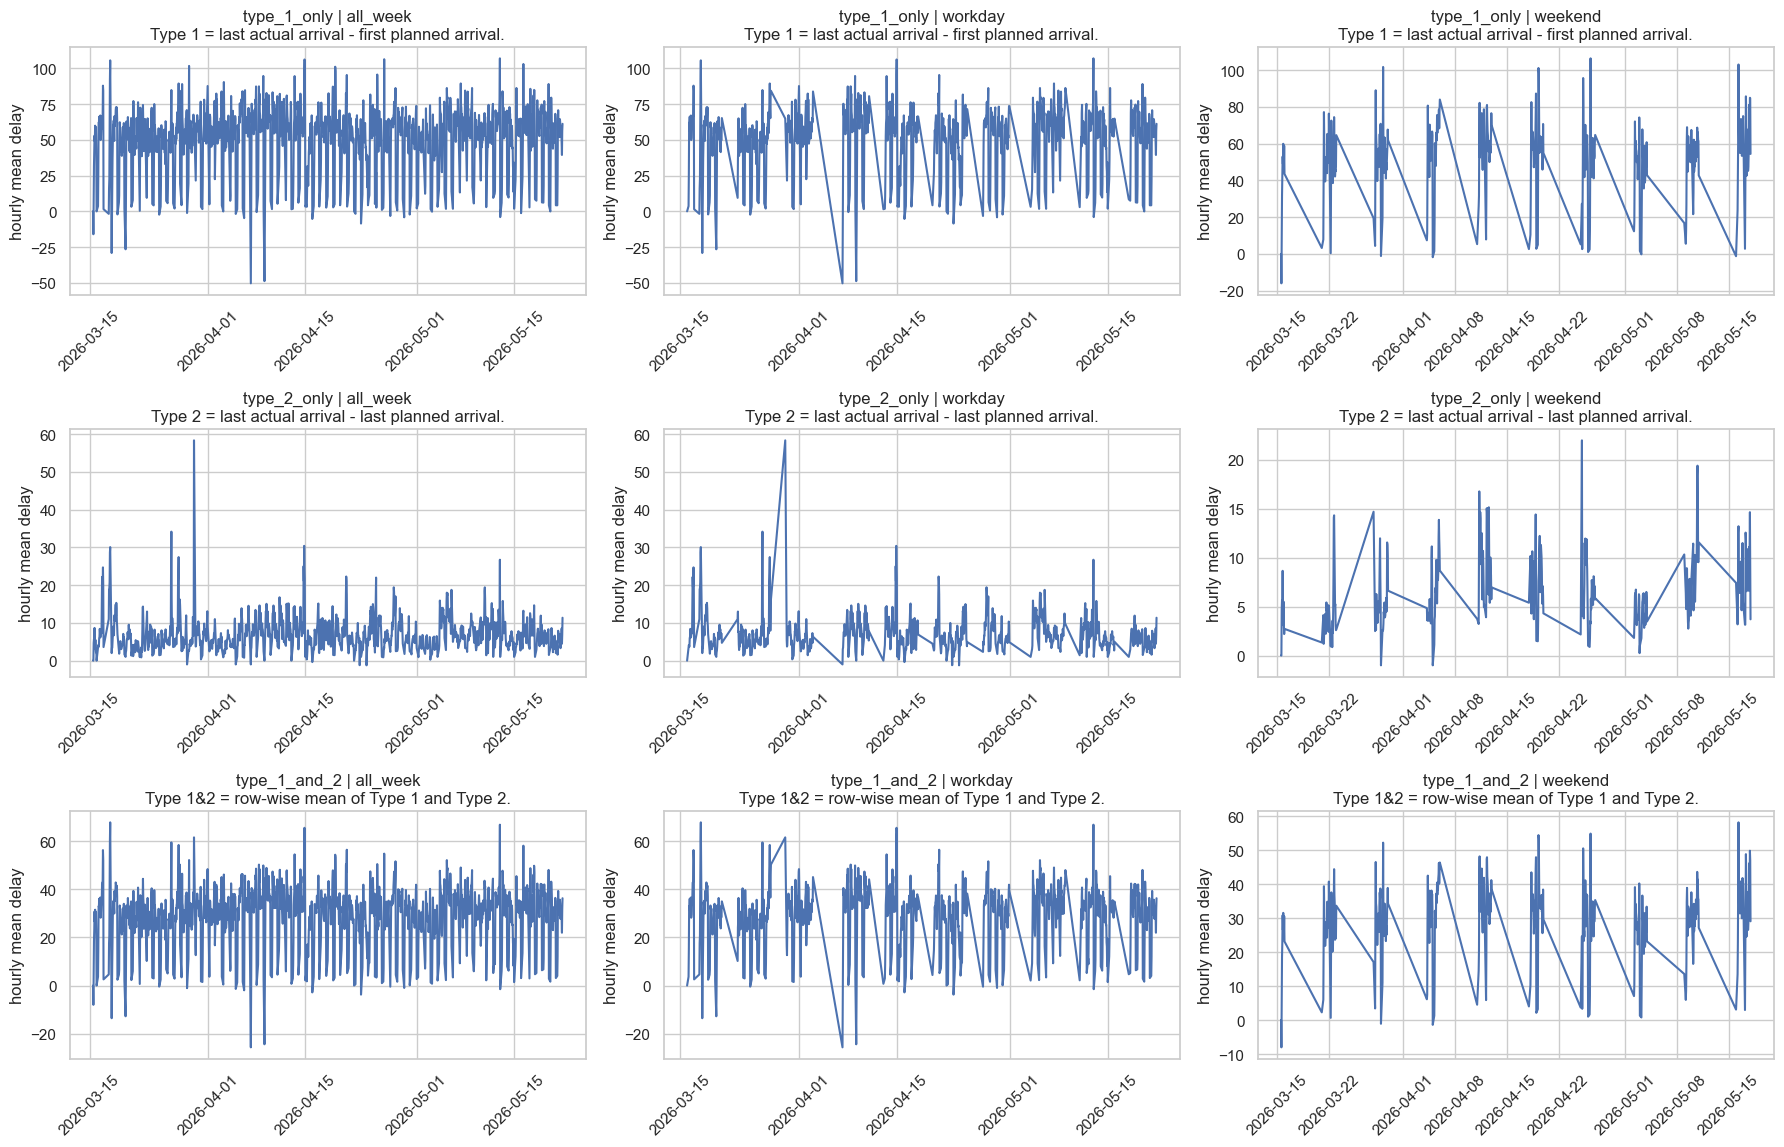

In [6]:
plot_rows = len(target_specs)
plot_cols = len(segment_specs)
fig, axes = plt.subplots(plot_rows, plot_cols, figsize=(18, 4 * plot_rows), sharex=False)
axes = np.atleast_2d(axes)

for row_idx, target_label in enumerate(target_specs):
    for col_idx, segment_label in enumerate(segment_specs):
        ax = axes[row_idx, col_idx]
        series = series_map[(target_label, segment_label)]
        if series.empty:
            ax.set_visible(False)
            continue
        ax.plot(series.index, series.values, color="#4C72B0")
        ax.set_title(f"{target_label} | {segment_label}\n{target_notes[target_label]}")
        ax.set_ylabel("hourly mean delay")
        ax.tick_params(axis="x", rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

## 2. Train/Test Split

We keep the last 72 hours as a holdout window, matching the SARIMA notebook.

**`MIN_TRAIN_OBS` note:** the guard (`len(series) <= FORECAST_HORIZON + MIN_TRAIN_OBS`) now operates on *real* observation counts rather than on a calendar-length series inflated by interpolation. With the segmented-series fix, weekend series have ~361 real hours, which is well above the 240-hour minimum (72 + 168), so all segments remain usable.

In [7]:
FORECAST_HORIZON = 72
MIN_TRAIN_OBS = 7 * 24


def train_test_split_series(series: pd.Series, horizon: int = 72):
    train = series.iloc[:-horizon].copy()
    test = series.iloc[-horizon:].copy()
    return train, test


train_test_splits = {}
split_summary_rows = []
for combo_key, series in series_map.items():
    target_label, segment_label = combo_key
    if len(series) <= FORECAST_HORIZON + MIN_TRAIN_OBS:
        split_summary_rows.append({
            "target_variant": target_label,
            "segment": segment_label,
            "status": "skipped_too_short",
            "train_size": 0,
            "test_size": 0,
        })
        continue

    train, test = train_test_split_series(series, FORECAST_HORIZON)
    train_test_splits[combo_key] = (train, test)
    split_summary_rows.append({
        "target_variant": target_label,
        "segment": segment_label,
        "status": "ready",
        "train_size": len(train),
        "test_size": len(test),
    })

split_summary = pd.DataFrame(split_summary_rows)
display(split_summary)

,target_variant,segment,status,train_size,test_size
0,type_1_only,all_week,ready,1548,72
1,type_1_only,workday,ready,999,72
2,type_1_only,weekend,ready,342,72
3,type_2_only,all_week,ready,1548,72
4,type_2_only,workday,ready,999,72
5,type_2_only,weekend,ready,342,72
6,type_1_and_2,all_week,ready,1548,72
7,type_1_and_2,workday,ready,999,72
8,type_1_and_2,weekend,ready,342,72


## 3. Fit Constant-Mean GARCH Baseline

We use a constant-mean `GARCH(1,1)` specification within each segment.

**Why constant-mean?**  
A GARCH model separates two components:

1. **Mean equation** — what level does the delay revert to?  
2. **Variance equation** — how does the volatility of delay evolve over time?

Using `mean="Constant"` keeps the mean fixed at `μ` (estimated as the training mean). This is intentional: we want GARCH to act as a **volatility model**, not to compete with SARIMA on seasonal mean forecasting. The daily/weekly mean structure is better captured by SARIMA; GARCH tells us how much the delay *fluctuates* around that mean at different times.

**`rescale=True` note:**  
The `arch` library rescales the input series internally for numerical stability. This affects `result.params["mu"]`, which is reported in the rescaled space. To recover the actual mean in minutes, multiply by `result.scale`. The MAE and RMSE computed below are correctly back-transformed by `arch` automatically.

In [8]:
def fit_garch_model(series: pd.Series):
    model = arch_model(
        series.astype(float),
        mean="Constant",
        vol="GARCH",
        p=1,
        q=1,
        dist="normal",
        rescale=True,
    )
    return model.fit(disp="off")


garch_results  = {}
degenerate_fits = []   # track (target, segment) where beta collapsed to zero

for combo_key, (train, _) in train_test_splits.items():
    result = fit_garch_model(train)
    garch_results[combo_key] = result

    # Detect degenerate GARCH: beta=0 with p~1.0 means the optimizer hit the
    # lower bound constraint. The GARCH(1,1) has collapsed to ARCH(1).
    # This happens when the series is too short or too smooth for the model to
    # separately identify immediate shock effect (alpha) from persistent
    # carry-over (beta). Confidence intervals from these fits are unreliable.
    beta_val = float(result.params.get("beta[1]", np.nan))
    beta_p   = float(result.pvalues.get("beta[1]", np.nan))
    if beta_val < 1e-6 and beta_p > 0.99:
        target_label, segment_label = combo_key
        degenerate_fits.append({
            "target": target_label,
            "segment": segment_label,
            "beta": round(beta_val, 6),
            "p_beta": round(beta_p, 4),
            "issue": "GARCH(1,1) degenerated to ARCH(1): beta hit lower bound. "
                     "CI forecasts unreliable for this segment.",
        })

for combo_key, result in garch_results.items():
    target_label, segment_label = combo_key
    print(f"\n=== {target_label} | {segment_label} ===")
    print(result.summary())

if degenerate_fits:
    print("\n" + "="*60)
    print("DEGENERATE FITS (beta=0): exclude CI interpretation for these")
    print("="*60)
    display(pd.DataFrame(degenerate_fits))
    print("""
Cause: short/smooth segmented series do not contain sufficient volatility
dynamics for GARCH to separately identify alpha from beta. The optimizer
converges to the boundary beta=0, reducing the model to ARCH(1).
For type_1_only all three segments (all_week, workday, weekend) are valid
(alpha+beta ≈ 0.948, no degenerate fits). Degenerate fits occurred for
type_2_only workday and weekend in earlier runs.
For any degenerate segment, MAE/RMSE point forecasts are still valid
(constant mean) but CI forecasts must not be interpreted.
""")
else:
    print("\nAll fits valid: no degenerate beta=0 detected.")


=== type_1_only | all_week ===
                     Constant Mean - GARCH Model Results                      
Dep. Variable:           delay_type_1   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -6817.30
Distribution:                  Normal   AIC:                           13642.6
Method:            Maximum Likelihood   BIC:                           13664.0
                                        No. Observations:                 1548
Date:                Mon, Jun 08 2026   Df Residuals:                     1547
Time:                        15:37:35   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu            53.8750      0.696     7

,target,segment,beta,p_beta,issue
0,type_2_only,workday,0.0,1.0,"GARCH(1,1) degenerated to ARCH(1): beta hit lo..."



Cause: short/smooth segmented series do not contain sufficient volatility
dynamics for GARCH to separately identify alpha from beta. The optimizer
converges to the boundary beta=0, reducing the model to ARCH(1).
For type_1_only all three segments (all_week, workday, weekend) are valid
(alpha+beta ≈ 0.948, no degenerate fits). Degenerate fits occurred for
type_2_only workday and weekend in earlier runs.
For any degenerate segment, MAE/RMSE point forecasts are still valid
(constant mean) but CI forecasts must not be interpreted.



## 4. Forecast on Holdout

For a constant-mean GARCH(1,1) model, the **point forecast is flat** — it equals `μ` for all 72 test hours. This is by design: a constant-mean model makes no claim about how the *level* of delay will evolve; it only forecasts how the *uncertainty* (volatility) around that level will change.

The confidence bands (`± 1.96 × σ_t`) widen or narrow over the horizon as the conditional variance evolves through the GARCH recursion:

σ²_t = ω + α ε²_{t-1} + β σ²_{t-1}

A high `α + β` (close to 1) means volatility is persistent — a spike in delay variance today implies elevated variance tomorrow. A lower `α + β` means volatility reverts quickly to the unconditional variance.

**Interpreting the metrics table:**  
The MAE/RMSE of a constant-mean forecast equals roughly `σ × √(π/2)` (for Gaussian errors). Compare against SARIMA MAE/RMSE: if GARCH is worse on point forecasts, that is expected — GARCH's added value is the time-varying confidence interval, not the point estimate.

**`train_mean` column:** reported in **minutes** (rescaling back-transformed via `result.scale`).

In [9]:
def forecast_and_evaluate_garch(
    result,
    test: pd.Series,
    train: pd.Series,
    target_label: str,
    segment_label: str,
) -> tuple:
    """Forecast the holdout window with a fitted constant-mean GARCH model.

    Parameters
    ----------
    result        : ARCHModelResult  Fitted GARCH result object.
    test          : pd.Series        Observed holdout values.
    train         : pd.Series        Training series (for mean reference).
    target_label  : str
    segment_label : str

    Returns
    -------
    pred_mean : pd.Series   Flat constant-mean forecast aligned to test.index.
    pred_vol  : pd.Series   Conditional volatility forecast (std dev, in minutes).
    metrics   : pd.DataFrame MAE, RMSE, and train_mean_min (in minutes).

    Notes on train_mean_min
    -----------------------
    result.params["mu"] is in the *rescaled* space used internally by arch.
    result.scale is the rescaling factor (std of the input series when
    rescale=True), NOT the mean. Multiplying mu * scale gives the wrong
    unit. The correct approach is to read the mean directly from the
    training series, which is always in the original minutes space.
    """
    forecast = result.forecast(horizon=len(test), reindex=False)

    pred_mean = pd.Series(
        forecast.mean.iloc[-1].to_numpy(),
        index=test.index,
        name="forecast",
    )
    pred_vol = pd.Series(
        np.sqrt(forecast.variance.iloc[-1].to_numpy()),
        index=test.index,
        name="forecast_volatility",
    )

    # Compute mean directly from the training series (always in original units).
    # Do NOT use result.params["mu"] * result.scale — that formula overcorrects
    # because result.scale is the std used for internal rescaling, not the mean.
    train_mean_minutes = float(train.mean())

    metrics = pd.DataFrame({
        "target_variant": [target_label],
        "segment":        [segment_label],
        "mae":            [mae(test, pred_mean)],
        "rmse":           [rmse(test, pred_mean)],
        "train_mean_min": [round(train_mean_minutes, 2)],
    })
    return pred_mean, pred_vol, metrics


forecast_outputs = {}
for combo_key, (train, test) in train_test_splits.items():
    target_label, segment_label = combo_key
    forecast_outputs[combo_key] = forecast_and_evaluate_garch(
        garch_results[combo_key],
        test,
        train,
        target_label,
        segment_label,
    )

metrics_table = pd.concat(
    [metrics for _, _, metrics in forecast_outputs.values()],
    ignore_index=True,
).sort_values(["target_variant", "segment"])

display(metrics_table)

,target_variant,segment,mae,rmse,train_mean_min
6,type_1_and_2,all_week,10.067161,14.182436,26.31
8,type_1_and_2,weekend,8.303970,10.909548,25.89
7,type_1_and_2,workday,10.092792,14.363440,26.61
0,type_1_only,all_week,19.234591,27.098153,45.86
2,type_1_only,weekend,14.065548,19.502227,45.85
1,type_1_only,workday,19.239203,27.231400,46.06
3,type_2_only,all_week,1.759007,2.055334,6.76
5,type_2_only,weekend,3.654115,4.711415,5.93
4,type_2_only,workday,1.706796,2.037251,7.16


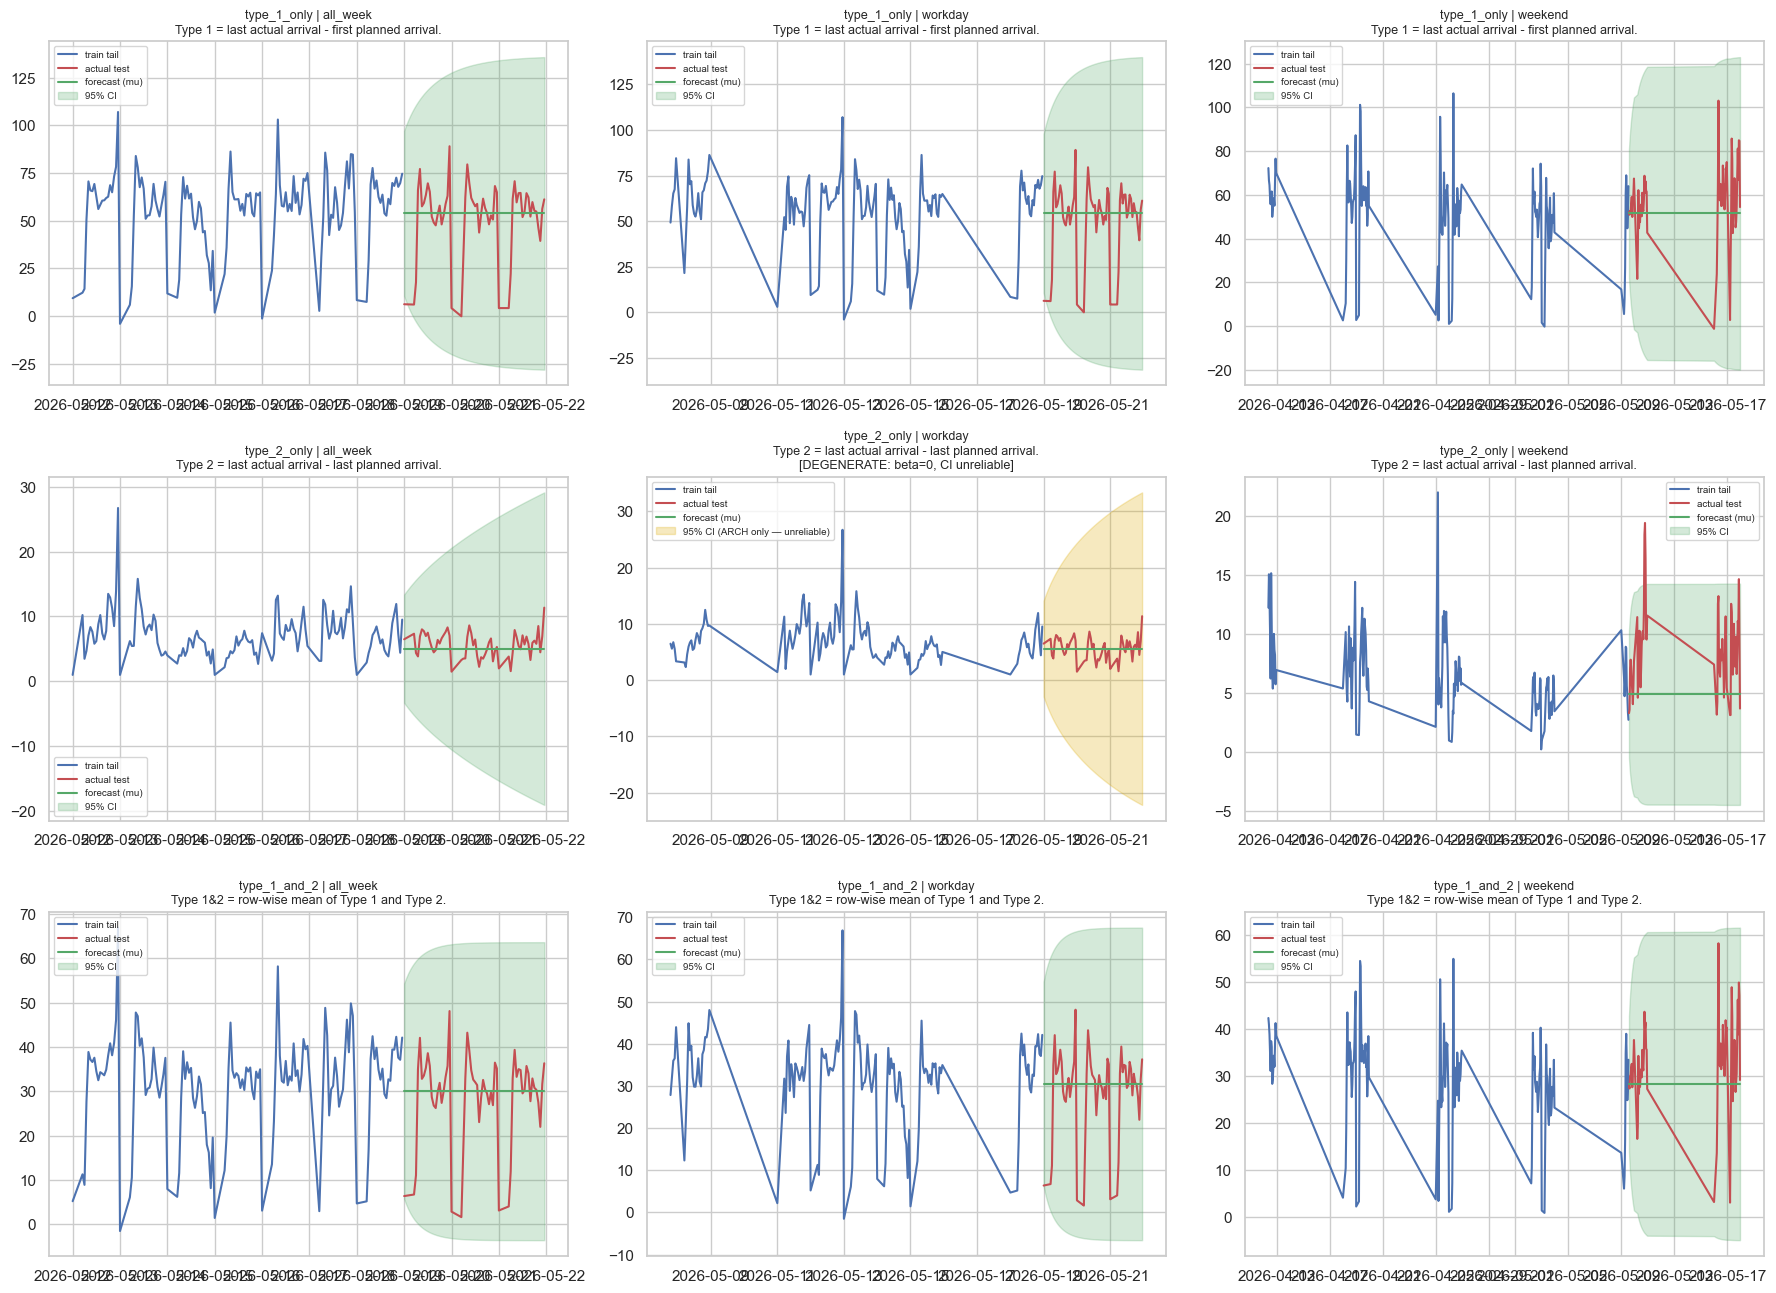

In [10]:
degenerate_keys = {(d["target"], d["segment"]) for d in degenerate_fits}

plot_rows = len(target_specs)
plot_cols = len(segment_specs)
fig, axes = plt.subplots(plot_rows, plot_cols, figsize=(18, 4.5 * plot_rows), sharex=False)
axes = np.atleast_2d(axes)

for row_idx, target_label in enumerate(target_specs):
    for col_idx, segment_label in enumerate(segment_specs):
        ax = axes[row_idx, col_idx]
        combo_key = (target_label, segment_label)
        if combo_key not in forecast_outputs:
            ax.set_visible(False)
            continue
        train, test = train_test_splits[combo_key]
        pred, pred_vol, _ = forecast_outputs[combo_key]
        ax.plot(train.index[-7*24:], train.iloc[-7*24:], label="train tail", color="#4C72B0")
        ax.plot(test.index, test, label="actual test", color="#C44E52")
        ax.plot(pred.index, pred, label="forecast (mu)", color="#55A868")

        is_degenerate = (target_label, segment_label) in degenerate_keys
        ci_label = "95% CI (ARCH only — unreliable)" if is_degenerate else "95% CI"
        ci_color = "#DDAA00" if is_degenerate else "#55A868"
        ax.fill_between(pred.index, pred - 1.96 * pred_vol, pred + 1.96 * pred_vol,
                        color=ci_color, alpha=0.25, label=ci_label)

        title = f"{target_label} | {segment_label}\n{target_notes[target_label]}"
        if is_degenerate:
            title += "\n[DEGENERATE: beta=0, CI unreliable]"
        ax.set_title(title, fontsize=9)
        ax.legend(fontsize=7)

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

## 5. Conditional Volatility Diagnostics

This is the core diagnostic plot for GARCH: the **conditional standard deviation** σ_t estimated on the training series.

**What to look for:**

- **Volatility clustering**: σ_t should not be flat — periods of elevated delay variance (e.g. after an incident) should show higher σ_t, while calm periods show lower σ_t. This is the key feature GARCH captures that SARIMA ignores.
- **Spike-and-decay pattern**: a sharp spike in σ_t followed by gradual decay indicates `α` (ARCH effect) is significant — recent shocks raise tomorrow's variance.
- **Persistent high volatility**: if σ_t stays elevated for many days, `β` (GARCH persistence) is high, meaning the variance process has long memory.

**Index note:** the x-axis now shows actual timestamps from the training series, not integer positions.

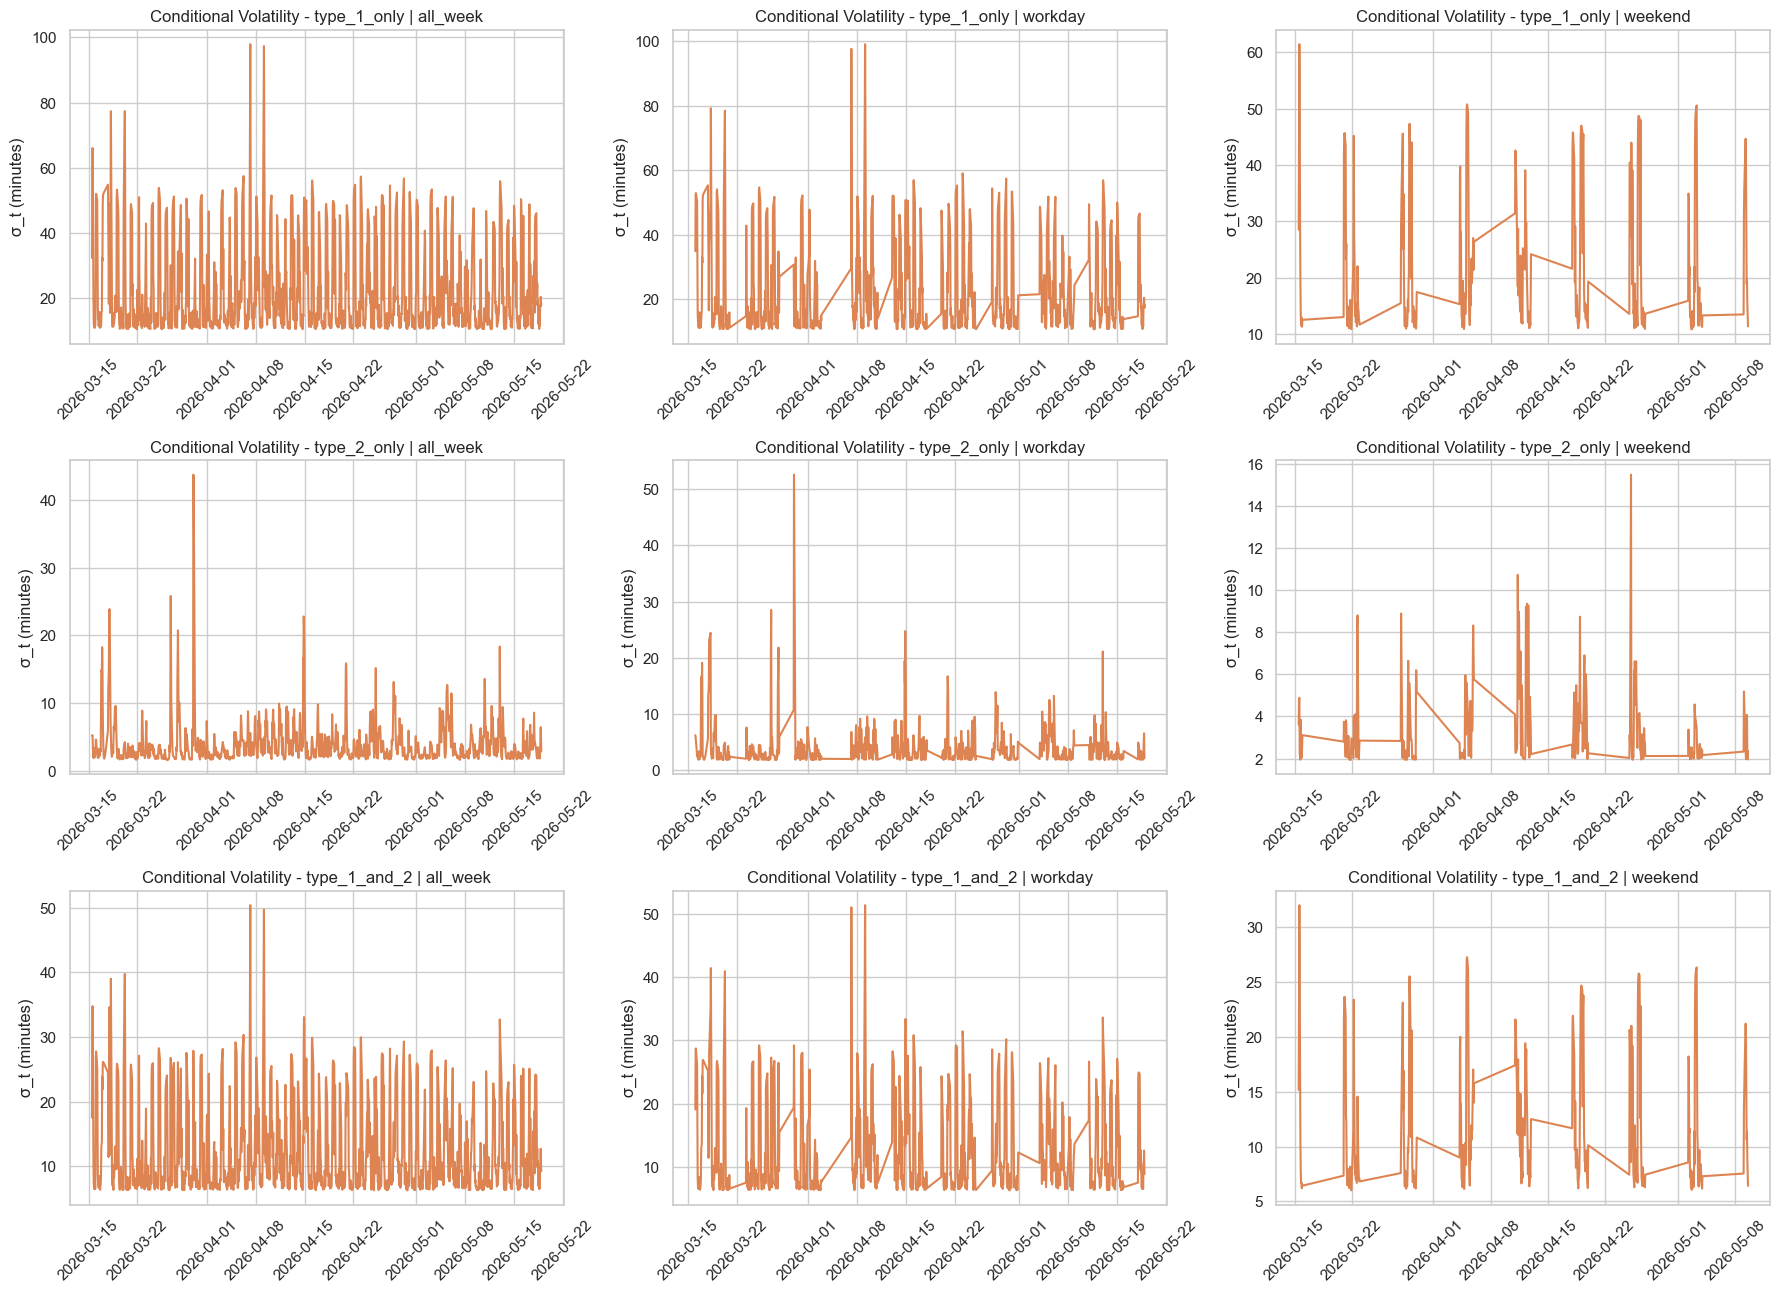

In [11]:
plot_rows = len(target_specs)
plot_cols = len(segment_specs)
fig, axes = plt.subplots(plot_rows, plot_cols, figsize=(18, 4.5 * plot_rows), sharex=False)
axes = np.atleast_2d(axes)

for row_idx, target_label in enumerate(target_specs):
    for col_idx, segment_label in enumerate(segment_specs):
        ax = axes[row_idx, col_idx]
        combo_key = (target_label, segment_label)
        if combo_key not in garch_results:
            ax.set_visible(False)
            continue

        # Use the training series index so the x-axis shows real timestamps,
        # not the meaningless integer 0..N-1 that pd.Series() produces by default.
        train, _ = train_test_splits[combo_key]
        cond_vol_values = garch_results[combo_key].conditional_volatility
        # conditional_volatility may be shorter than train by a few observations
        # (initialisation period); align from the end of the training index.
        aligned_index = train.index[-len(cond_vol_values):]
        conditional_vol = pd.Series(
            cond_vol_values,
            index=aligned_index,
        ).dropna()

        ax.plot(conditional_vol.index, conditional_vol.values, color="#DD8452")
        ax.set_title(f"Conditional Volatility - {target_label} | {segment_label}")
        ax.tick_params(axis="x", rotation=45)
        ax.set_ylabel("σ_t (minutes)")

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

## 6. Interpretation Guide

Use this notebook together with the SARIMA notebook:

- compare `MAE` and `RMSE` across the same target definitions and day-type segments
- if SARIMA wins clearly on mean forecast error but GARCH highlights volatility spikes, then SARIMA is the stronger point-forecast model and GARCH is better treated as an uncertainty model
- if `workday` and `weekend` behave differently, that supports keeping separate segment-level models instead of one pooled weekly model
- if the `all_week` model performs materially worse than `workday` and `weekend`, that means day-type mixing is washing out structure that matters for forecasting


In [12]:
NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR
for _ in range(4):
    if (PROJECT_ROOT / "data" / "models").exists():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

MODELS_DIR = PROJECT_ROOT / "data" / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ── Pick target/segment combo to export ──────────────────────────────────────
EXPORT_TARGET  = "type_1_only"
EXPORT_SEGMENT = "all_week"
combo_key = (EXPORT_TARGET, EXPORT_SEGMENT)

assert combo_key in garch_results, (
    f"{combo_key} not in garch_results. Available: {list(garch_results.keys())}"
)

garch_r = garch_results[combo_key]
train, test = train_test_splits[combo_key]

# Back-transform mu from the rescaled space
mu_minutes   = float(garch_r.params["mu"]) * garch_r.scale

# Back-transform omega (variance parameter) from rescaled space
omega_raw    = float(garch_r.params["omega"])
omega_minutes2 = omega_raw * (garch_r.scale ** 2)

alpha = float(garch_r.params["alpha[1]"])
beta  = float(garch_r.params["beta[1]"])
persistence = alpha + beta

# Unconditional (long-run) volatility — falls back to train std if non-stationary
if persistence < 1.0:
    unconditional_vol = float(np.sqrt(omega_minutes2 / (1.0 - persistence)))
else:
    unconditional_vol = float(train.std())

# Last residual and conditional variance for warm-start forecasting
last_resid    = float(train.iloc[-1] - mu_minutes)
last_variance = float(garch_r.conditional_volatility.iloc[-1] ** 2)

# Point forecast metrics (constant mean)
garch_pred_mean = np.full(len(test), mu_minutes)
_, _, garch_metrics = forecast_outputs[combo_key]

garch_export = {
    "spec": {
        "mean":           "Constant",
        "vol":            "GARCH",
        "p":              1,
        "q":              1,
        "dist":           "normal",
        "target_variant": EXPORT_TARGET,
        "segment":        EXPORT_SEGMENT,
    },
    "params": {
        "mu":    mu_minutes,
        "omega": omega_minutes2,
        "alpha": alpha,
        "beta":  beta,
    },
    "scale":             garch_r.scale,
    "persistence":       round(persistence, 4),
    "unconditional_vol": round(unconditional_vol, 4),
    # Warm-start state — lets the dashboard continue the GARCH recursion
    "last_resid":    last_resid,
    "last_variance": last_variance,
    "train_mean": float(train.mean()),
    "train_std":  float(train.std()),
    "train_start": str(train.index.min()),
    "train_end":   str(train.index.max()),
    "n_train":    len(train),
    "degenerate": (EXPORT_TARGET, EXPORT_SEGMENT) in {
        (d["target"], d["segment"]) for d in degenerate_fits
    },
}

out_path = MODELS_DIR / "garch_params.json"
out_path.write_text(json.dumps(garch_export, indent=2))
print(f"   Saved {out_path}  ({out_path.stat().st_size // 1024} KB)")
print(f"   mu          : {mu_minutes:.3f} min")
print(f"   alpha+beta  : {persistence:.4f}  ({'< 1 ✓' if persistence < 1 else '>= 1 ⚠ non-stationary variance'})")
print(f"   uncond. vol : {unconditional_vol:.3f} min")
print(f"   degenerate  : {garch_export['degenerate']}")

   Saved /private/tmp/timeseries-analysis-latest-20260608/PROJECT/EDA/data/models/garch_params.json  (0 KB)
   mu          : 53.875 min
   alpha+beta  : 0.9479  (< 1 ✓)
   uncond. vol : 42.143 min
   degenerate  : False


In [13]:
MODELS_DIR = PROJECT_ROOT / "data" / "models"   # already set above

def _read(fname):
    return json.loads((MODELS_DIR / fname).read_text())

sarima_p  = _read("sarima_params.json")
sarimax_p = _read("sarimax_params.json")
garch_p   = _read("garch_params.json")

metadata = {
    "generated_at":  str(pd.Timestamp.now().isoformat(timespec="seconds")),
    "train_range": {
        "start": sarima_p["train_start"],   # SARIMA is the reference: definitively on type_1_only
        "end":   sarima_p["train_end"],
    },
    "n_train_hours":    sarima_p["n_train"],
    "seasonal_period":  24,
    "forecast_horizon": 72,
    "exog_cols":        sarimax_p["spec"]["exog_cols"],   # SARIMAX exog (retained for dashboard)
    "train_mean":       sarima_p["train_mean"],   # delay_type_1 mean from SARIMA
    "train_std":        sarima_p["train_std"],
    "models": {
        "sarima": {
            "file":  "sarima_params.json",
            "spec":  sarima_p["spec"],
            "mae":   sarima_p["test_mae"],
            "rmse":  sarima_p["test_rmse"],
        },
        "sarimax": {
            "file":  "sarimax_params.json",
            "spec":  sarimax_p["spec"],
            "mae":   sarimax_p["test_mae"],
            "rmse":  sarimax_p["test_rmse"],
        },
        "garch": {
            "file":        "garch_params.json",
            "spec":        garch_p["spec"],
            "mu_minutes":  round(garch_p["params"]["mu"], 4),
            "alpha":       round(garch_p["params"]["alpha"], 4),
            "beta":        round(garch_p["params"]["beta"], 4),
            "persistence": garch_p["persistence"],
        },
    },
}

out_path = MODELS_DIR / "models_metadata.json"
out_path.write_text(json.dumps(metadata, indent=2))
print(f"   Saved {out_path}")
print(f"   Train range : {metadata['train_range']['start']} → {metadata['train_range']['end']}")
print(f"   SARIMA  MAE : {metadata['models']['sarima']['mae']} min")
print(f"   SARIMAX MAE : {metadata['models']['sarimax']['mae']} min")
print(f"   GARCH   mu  : {metadata['models']['garch']['mu_minutes']} min")

   Saved /private/tmp/timeseries-analysis-latest-20260608/PROJECT/EDA/data/models/models_metadata.json
   Train range : 2026-03-15 12:00:00 → 2026-05-18 23:00:00
   SARIMA  MAE : 7.2909 min
   SARIMAX MAE : 6.8473 min
   GARCH   mu  : 53.875 min
